<a href="https://colab.research.google.com/github/pranavkerkar31/Facial-Expression-Recognition/blob/main/EfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load the libraries

In [1]:
!pip install kaggle # to downlaod the dataset
!pip install opencv-python # video capturing
!pip install tensorflow # cnn model training
!pip install scikit-learn # for evaluation metrics
!pip install matplotlib # graphs

Upload Kaggle json to Collab

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pranavkerkar31","key":"949448ce59f330c85b04484a490862cb"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Download and unzip

In [4]:


!kaggle datasets download -d msambare/fer2013
!unzip fer2013.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/sad/Training_65242339.jpg  
  inflating: train/sad/Training_65267116.jpg  
  inflating: train/sad/Training_65275626.jpg  
  inflating: train/sad/Training_6529266.jpg  
  inflating: train/sad/Training_65329617.jpg  
  inflating: train/sad/Training_65338712.jpg  
  inflating: train/sad/Training_65338797.jpg  
  inflating: train/sad/Training_65387162.jpg  
  inflating: train/sad/Training_65404494.jpg  
  inflating: train/sad/Training_65426218.jpg  
  inflating: train/sad/Training_65430136.jpg  
  inflating: train/sad/Training_65437377.jpg  
  inflating: train/sad/Training_6545735.jpg  
  inflating: train/sad/Training_65463385.jpg  
  inflating: train/sad/Training_65473985.jpg  
  inflating: train/sad/Training_65502829.jpg  
  inflating: train/sad/Training_65505359.jpg  
  inflating: train/sad/Training_65508578.jpg  
  inflating: train/sad/Training_65516023.jpg  
  inflating: train/sad/Training_65524027.jpg  
  inflating

Define the dataset

In [5]:
train = "/content/train"
test="/content/test"

Import the libraries for the ResNet

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

Preprocessing the dataset

In [9]:
from tensorflow.keras.applications.resnet50 import preprocess_input
train_preprocess = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_preprocess = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

Load the preprocessed dataset

In [10]:
train_generator = train_preprocess.flow_from_directory(
    train,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    color_mode="rgb"
)

test_generator = test_preprocess.flow_from_directory(
    test,
    target_size = (224,224),
    batch_size=32,
    class_mode = "categorical",
    color_mode="rgb",
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


Load the ResNet Model

In [12]:
base_model=EfficientNetB0(
    weights = "imagenet",
    include_top=False,
    input_shape = (224,224,3)
)

# freezing the pretrained model

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-50:]:
    layer.trainable = True

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Custom Layer

In [17]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x) # prevents overfitting
predictions = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

Compile Model

In [18]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Train the model

In [19]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20
)

Epoch 1/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 390s 404ms/step - accuracy: 0.6645 - loss: 0.9205 - val_accuracy: 0.5982 - val_loss: 1.1225
Epoch 2/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 333s 371ms/step - accuracy: 0.6992 - loss: 0.8248 - val_accuracy: 0.5919 - val_loss: 1.1488
Epoch 3/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 335s 373ms/step - accuracy: 0.7056 - loss: 0.8017 - val_accuracy: 0.5921 - val_loss: 1.1597
Epoch 4/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 335s 373ms/step - accuracy: 0.7173 - loss: 0.7718 - val_accuracy: 0.6028 - val_loss: 1.1643
Epoch 5/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 335s 373ms/step - accuracy: 0.7194 - loss: 0.7637 - val_accuracy: 0.6089 - val_loss: 1.1525
Epoch 6/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 330s 368ms/step - accuracy: 0.7269 - loss: 0.7370 - val_accuracy: 0.6127 - val_loss: 1.1741
Epoch 7/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 334s 372ms/step - accuracy: 0.7388 - loss: 0.7114 - val_accuracy: 0.6080 - val_loss: 1.1747
Epoch 8/20
898/898 ━━━━━━━━━━━━━━━━━━━━ 330s 367ms/step - accuracy: 0.7418 -

KeyboardInterrupt: 

Saving the model

In [ ]:
model.save("emotion_efficient50_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


225/225 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step
Accuracy: 0.6422401783226526
              precision    recall  f1-score   support

       angry       0.52      0.66      0.58       958
     disgust       0.68      0.44      0.54       111
        fear       0.47      0.53      0.50      1024
       happy       0.89      0.83      0.86      1774
     neutral       0.57      0.65      0.61      1233
         sad       0.57      0.39      0.46      1247
    surprise       0.76      0.76      0.76       831

    accuracy                           0.64      7178
   macro avg       0.64      0.61      0.61      7178
weighted avg       0.65      0.64      0.64      7178



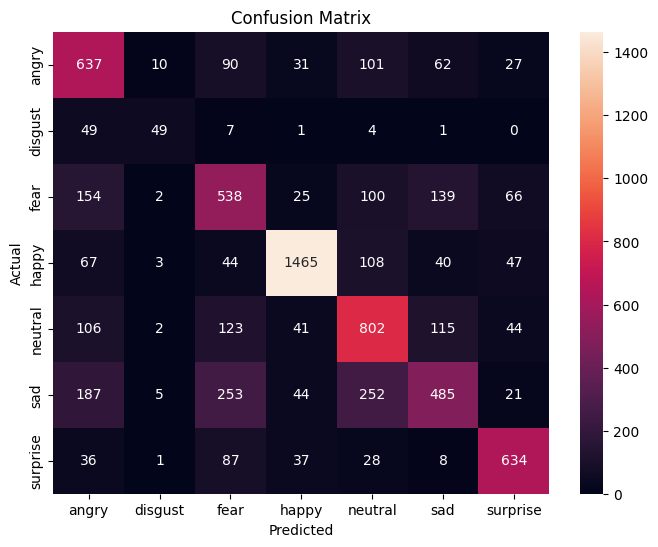

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

test_generator.reset()

predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

print("Accuracy:", accuracy_score(y_true, y_pred))

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()